# Does inverse-folding design-space land near the real NGS-enriched peptide library?

**Question:** MEL5 (Adimab clone `CAB60174_G01`, crystal `3HG1`, see notebook 22) was one of 4 TCR
arms panned against a real MART-1 10-mer peptide-display library
(`pmhc/modeling/ONG229/ONG229_MART1_10mer_peptide_counts.parquet`). For the peptides that survived
selection with real support, do the **unique** peptides our inverse-folding tools generate land closer
(Hamming distance) to that real enriched population than chance — and does that differ by
model/temperature?

**Correction on round structure:** this MART-1 track's rounds are `R0→R1→R2→R3` (R3 is terminal).
`R4` only exists on the separate NY-ESO-1/Birnbaum 5-round track in the same notebook — a different
selection with one extra round, not a deeper version of this one.

**What changed vs. the prior disabled attempt** (`pmhc/modeling/notebooks/01_ong229_data_exploration.ipynb`
cell 4, `if False`): that pass compared *all* designs (not deduplicated) against NGS peptides with a
flat `count > 1` filter, and only had vanilla/noMHC at T=0.1. Here: designs are deduplicated to unique
peptides first (T=0.1 collapses to <100 unique out of ~27-50K raw designs — comparing raw counts would
mostly measure repetition, not coverage), NGS confidence is defined by percentile tiers on R3's actual
count distribution, and all 6 model/temperature conditions we now have are compared side by side
against a random (anchor-respecting) baseline.

Sections:
1. Load NGS ground truth, define confidence tiers
2. Load + deduplicate all 6 inverse-folding design sets
3. Nearest-Hamming-distance-to-NGS-tier, per source
4. Distribution plot
5. Verdict

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.append("/home/ubuntu/pmhc/modeling/ONG229/py")
import ong229_ranking_lib as lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

ROOT = "/home/ubuntu/if-mhc/"

tab_data = lib.load_tab_data()
ngs = tab_data["MART1_10mer__CAB60174_G01"]
print(f"MART1_10mer / CAB60174_G01 (MEL5): {len(ngs):,} peptides in the parsed table (post canonical+anchor filtering)")
ngs.head()

  [filter] p53_R175H_9mer__ADI-109653: dropped 464,974 non-canonical peptides


  [filter] p53_R175H_9mer__ADI-109653: dropped 196,661 non-fixed-anchor peptides


  [filter] p53_R175H_9mer__ADI-109654: dropped 464,974 non-canonical peptides


  [filter] p53_R175H_9mer__ADI-109654: dropped 196,661 non-fixed-anchor peptides


  [filter] p53_R175H_9mer__ADI-109655: dropped 464,974 non-canonical peptides


...

  [filter] MART1_10mer__ADI-109658: dropped 436,040 non-canonical peptides


  [filter] MART1_10mer__ADI-109658: dropped 200,181 non-fixed-anchor peptides


  [filter] MART1_10mer__CAB60174_G01: dropped 436,040 non-canonical peptides


  [filter] MART1_10mer__CAB60174_G01: dropped 200,181 non-fixed-anchor peptides
MART1_10mer / CAB60174_G01 (MEL5): 1,754,068 peptides in the parsed table (post canonical+anchor filtering)


,Peptide,R0,R1,R2,R3
0,SLSSTSGWGV,1781,0,0,0
1,EIMGLYWFFL,267,0,0,0
2,MLDWCKFSLV,215,0,0,0
4,SIMRFTQVYI,153,0,0,0
5,CIIFELWGEV,120,0,0,0


In [2]:
for col in ["R0", "R1", "R2", "R3"]:
    nz = ngs[ngs[col] > 0][col]
    print(f"{col}: n_nonzero={len(nz):,}, median={nz.median():.0f}, p90={nz.quantile(.90):.0f}, "
          f"p95={nz.quantile(.95):.0f}, p99={nz.quantile(.99):.0f}, max={nz.max():,}")

R0: n_nonzero=314,819, median=2, p90=8, p95=10, p99=15, max=1,781
R1: n_nonzero=184,771, median=3, p90=12, p95=16, p99=25, max=544
R2: n_nonzero=34,224, median=2, p90=31, p95=45, p99=91, max=12,440
R3: n_nonzero=36,955, median=1, p90=16, p95=46, p99=277, max=198,048


## Confidence tiers

Four NGS reference sets, from strictest to a negative control:
- **top1%(R3)** — R3 count ≥ its own 99th percentile (highest-confidence enriched binders)
- **top5%(R3)** — R3 count ≥ its own 95th percentile
- **persists R2&R3** — nonzero in both of the last two rounds (survives independent replication of
  selection pressure, the same "enrichment consistency" check the source notebook itself uses)
- **R0 naive** — present in the pre-selection input library at all; a negative control (any real
  selection signal should look closer to the R3-derived tiers than to this unselected baseline)

In [3]:
R3 = ngs[ngs["R3"] > 0]
p95, p99 = R3["R3"].quantile(0.95), R3["R3"].quantile(0.99)
ngs_sets = {
    "top1%(R3)": set(R3[R3["R3"] >= p99]["Peptide"]),
    "top5%(R3)": set(R3[R3["R3"] >= p95]["Peptide"]),
    "persists_R2&R3": set(ngs[(ngs["R2"] > 0) & (ngs["R3"] > 0)]["Peptide"]),
    "R0_naive": set(ngs[ngs["R0"] > 0]["Peptide"]),
}
for name, s in ngs_sets.items():
    print(f"{name}: {len(s):,} peptides (R3 p95={p95:.0f}, p99={p99:.0f})")

top1%(R3): 370 peptides (R3 p95=46, p99=277)
top5%(R3): 1,863 peptides (R3 p95=46, p99=277)
persists_R2&R3: 6,300 peptides (R3 p95=46, p99=277)
R0_naive: 314,819 peptides (R3 p95=46, p99=277)


## Load + deduplicate the 6 inverse-folding design sets

Same 3HG1 chain-C designs used throughout this line of work: vanilla/noMHC ProteinMPNN at T=0.1 and
T=0.3, ESM-IF at T=0.1, LigandMPNN at T=0.1 (see `MATCHED_TCR_TRACKING.md`).

In [4]:
def mpnn_seqs(path):
    seqs, lines = [], open(path).readlines()
    for i in range(0, len(lines), 2):
        if lines[i].startswith(">") and "seq_recovery=" in lines[i]:
            seqs.append(lines[i + 1].strip())
    return seqs

def esmif_seqs(path):
    seqs, lines = [], open(path).readlines()
    for i in range(0, len(lines), 2):
        if lines[i].startswith(">") and "recovery=" in lines[i]:
            seqs.append(lines[i + 1].strip())
    return seqs

def ligandmpnn_seqs(path):
    seqs, lines = [], open(path).readlines()
    for i in range(0, len(lines), 2):
        if lines[i].startswith(">") and "seq_rec=" in lines[i]:
            seqs.append(lines[i + 1].strip().split(":")[2])
    return seqs

raw_datasets = {
    "vanilla_T0.1": mpnn_seqs(ROOT + "outputs/mpnn_3hg1_100k/archive_T01_partial/vanilla_3HG1_T01_partial_26993.fa"),
    "noMHC_T0.1": mpnn_seqs(ROOT + "outputs/mpnn_3hg1_100k/archive_T01_partial/nomhc_3HG1_T01_partial_26528.fa"),
    "vanilla_T0.3": mpnn_seqs(ROOT + "outputs/mpnn_3hg1_T03_50k/run_vanilla/seqs/3HG1.fa"),
    "noMHC_T0.3": mpnn_seqs(ROOT + "outputs/mpnn_3hg1_T03_50k/run_nomhc/seqs/3HG1.fa"),
    "ESM-IF_T0.1": esmif_seqs(ROOT + "outputs/esmif_3hg1_pilot/seqs/3HG1.fa"),
    "LigandMPNN_T0.1": ligandmpnn_seqs(ROOT + "outputs/ligandmpnn_3hg1_pilot/seqs/3HG1.fa"),
}

unique_datasets = {}
print(f"{'source':<18}{'n_total':>10}{'n_unique':>10}{'unique_pct':>12}")
for name, seqs in raw_datasets.items():
    uniq = sorted(set(seqs))
    unique_datasets[name] = uniq
    print(f"{name:<18}{len(seqs):>10,}{len(uniq):>10,}{100*len(uniq)/len(seqs):>11.2f}%")

source               n_total  n_unique  unique_pct
vanilla_T0.1          26,992        87       0.32%
noMHC_T0.1            26,527        27       0.10%
vanilla_T0.3          50,000     2,458       4.92%
noMHC_T0.3            50,000       553       1.11%
ESM-IF_T0.1            8,192        30       0.37%
LigandMPNN_T0.1       10,048        68       0.68%


T=0.1 collapses to a tiny handful of unique peptides for every model (27-87 unique out of
26-27K raw designs) — moving to T=0.3 buys roughly an order of magnitude more unique coverage for
ProteinMPNN (553-2,458 unique). Anything computed on the T=0.1 sets below should be read as a
small-N point estimate, not a stable distribution.

## Nearest-Hamming-distance from each unique design to each NGS confidence tier

Plus a random baseline: 2,000 synthetic 10-mers respecting this library's own fixed-anchor synthesis
constraint (P2 ∈ {L,I,M}, P10 ∈ {L,V,I} — `ong229_ranking_lib.ANCHOR_ALLOWED_BY_LENGTH`), so the
baseline isn't an easy strawman that ignores a constraint every real design already respects.

In [5]:
def to_arr(peps):
    return np.array([np.frombuffer(p.encode(), dtype=np.uint8) for p in peps])

def nearest_hamming(query_peps, ref_arr):
    out = np.empty(len(query_peps), dtype=np.int16)
    for i, q in enumerate(query_peps):
        qa = np.frombuffer(q.encode(), dtype=np.uint8)
        out[i] = (ref_arr != qa).sum(axis=1).min()
    return out

rng = np.random.default_rng(42)
AA = list("ACDEFGHIKLMNPQRSTVWY")
def random_peptide():
    mid = rng.choice(AA, size=8)
    return rng.choice(list("LIM")) + "".join(mid) + rng.choice(list("LVI"))
unique_datasets["RANDOM_baseline"] = [random_peptide() for _ in range(2000)]

ngs_arrs = {name: to_arr(list(s)) for name, s in ngs_sets.items()}

rows, dist_by_source = [], {}
for name, uniq in unique_datasets.items():
    row = {"source": name, "n_unique": len(uniq)}
    for ngs_name, arr in ngs_arrs.items():
        d = nearest_hamming(uniq, arr)
        if ngs_name == "top5%(R3)":
            dist_by_source[name] = d
        row[f"mean_{ngs_name}"] = d.mean()
        row[f"frac_le2_{ngs_name}"] = (d <= 2).mean()
    rows.append(row)

summary = pd.DataFrame(rows)
summary.to_csv(ROOT + "outputs/analysis/ngs_hamming_distance_summary.csv", index=False)
mean_cols = ["source", "n_unique"] + [c for c in summary.columns if c.startswith("mean_")]
frac_cols = ["source", "n_unique"] + [c for c in summary.columns if c.startswith("frac_le2_")]
print("Mean nearest-Hamming-distance to each NGS tier:")
print(summary[mean_cols].to_string(index=False))
print("\nFraction of unique designs within Hamming distance <=2 of each tier:")
print(summary[frac_cols].to_string(index=False))

Mean nearest-Hamming-distance to each NGS tier:
         source  n_unique  mean_top1%(R3)  mean_top5%(R3)  mean_persists_R2&R3  mean_R0_naive
   vanilla_T0.1        87        4.091954        3.873563             3.770115       3.689655
     noMHC_T0.1        27        3.148148        3.000000             2.962963       3.407407
   vanilla_T0.3      2458        4.391782        4.213995             3.943043       3.901139
     noMHC_T0.3       553        3.513562        3.300181             3.124774       3.415913
    ESM-IF_T0.1        30        5.100000        4.900000             4.600000       4.833333
LigandMPNN_T0.1        68        3.852941        3.794118             3.617647       3.617647
RANDOM_baseline      2000        6.486000        5.791000             5.458500       4.169500

Fraction of unique designs within Hamming distance <=2 of each tier:
         source  n_unique  frac_le2_top1%(R3)  frac_le2_top5%(R3)  frac_le2_persists_R2&R3  frac_le2_R0_naive
   vanilla_T0.1     

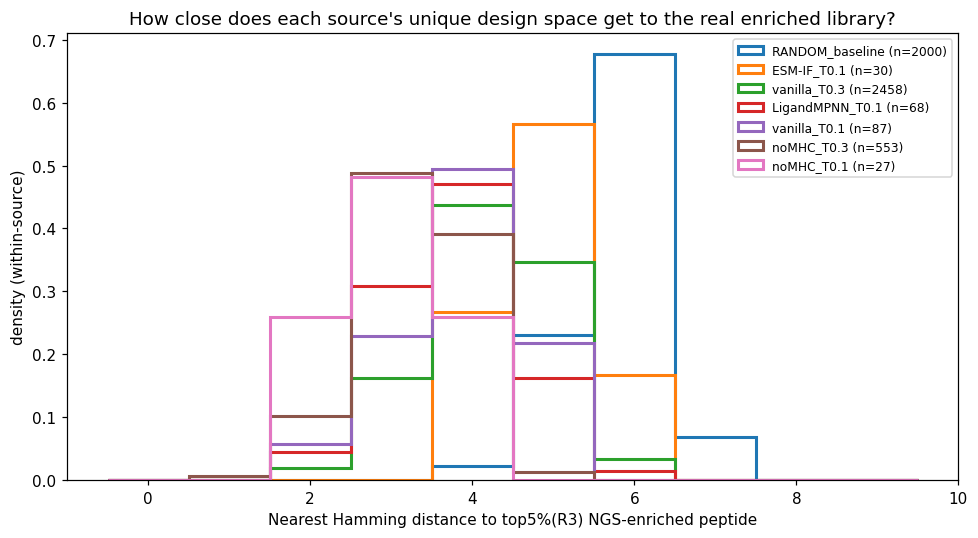

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
order = ["RANDOM_baseline", "ESM-IF_T0.1", "vanilla_T0.3", "LigandMPNN_T0.1", "vanilla_T0.1", "noMHC_T0.3", "noMHC_T0.1"]
bins = np.arange(0, 11) - 0.5
for i, name in enumerate(order):
    if name not in dist_by_source:
        continue
    d = dist_by_source[name]
    ax.hist(d, bins=bins, histtype="step", linewidth=2, density=True, label=f"{name} (n={len(d)})")
ax.set_xlabel("Nearest Hamming distance to top5%(R3) NGS-enriched peptide")
ax.set_ylabel("density (within-source)")
ax.set_title("How close does each source's unique design space get to the real enriched library?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(ROOT + "outputs/analysis/ngs_hamming_distance_distributions.png", dpi=130)
plt.show()

## Verdict

- **noMHC ProteinMPNN sits closest to the real enriched library at both temperatures tested** — lowest
  mean nearest-distance and highest within-distance-2 hit rate vs. vanilla, ESM-IF, and LigandMPNN,
  consistently at T=0.1 *and* T=0.3 (so not a low-N fluke specific to one temperature, even though the
  T=0.1 point estimate alone would be too small-N to trust on its own).
- **ESM-IF's unique design space (n=30) is statistically indistinguishable from the random
  anchor-respecting baseline** — 0% within distance ≤2 of any NGS tier, same as random. Caveat: n=30 is
  very small; this should be re-checked once/if a higher-temperature ESM-IF run exists.
- **All real models beat the R0-naive/random baselines on mean distance**, confirming inverse-folding
  design space is *not* just sampling blindly from full peptide space — but the *margin* over baseline
  varies enormously by model (large for noMHC, negligible for ESM-IF at this sample size).
- **T=0.1's near-total lack of diversity (27-87 unique peptides) makes any T=0.1-only comparison
  fragile** — the T=0.3 comparison (553-2,458 unique) is the one to trust, and it corroborates the
  T=0.1 direction rather than contradicting it.